In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Check columns
print(df.columns)

# Rename columns (if needed for easy use)
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check missing values
print(df.isnull().sum())

# Drop missing values
df = df.dropna()

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [4]:
print(df.describe())
print(df['Region'].unique())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500

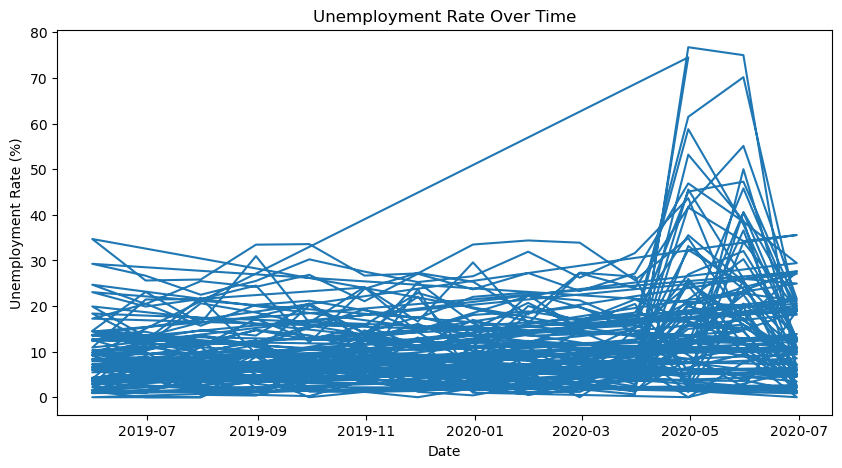

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

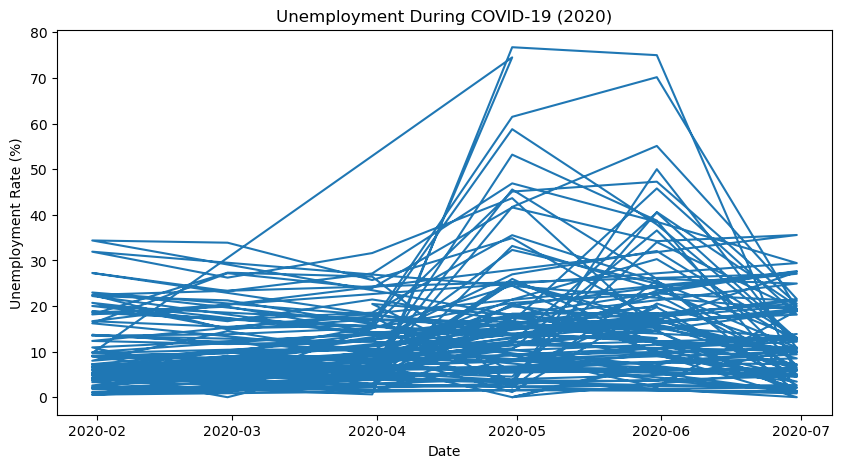

In [6]:
covid_data = df[df['Date'].dt.year == 2020]

plt.figure(figsize=(10,5))
plt.plot(covid_data['Date'], covid_data['Estimated Unemployment Rate (%)'])
plt.title('Unemployment During COVID-19 (2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

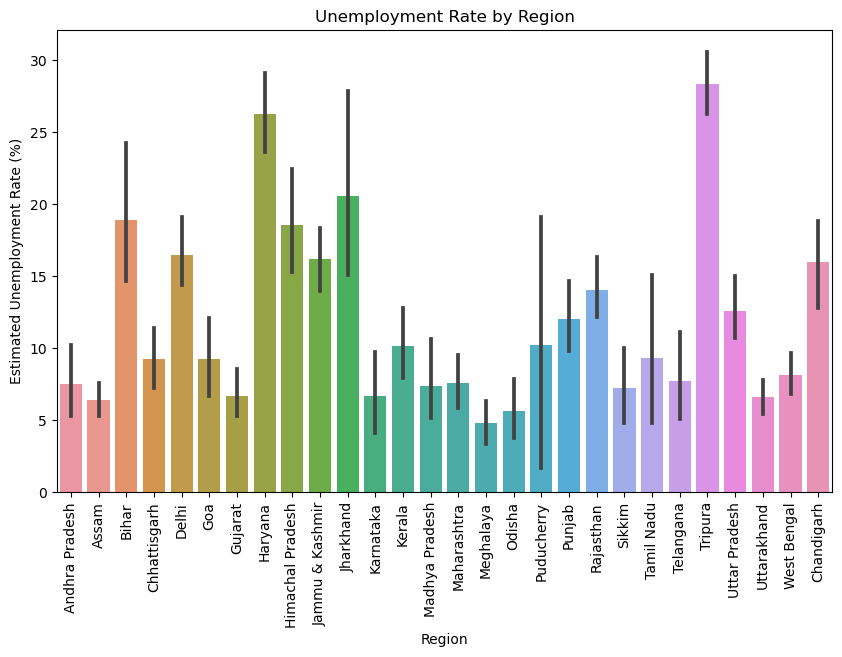

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title('Unemployment Rate by Region')
plt.show()

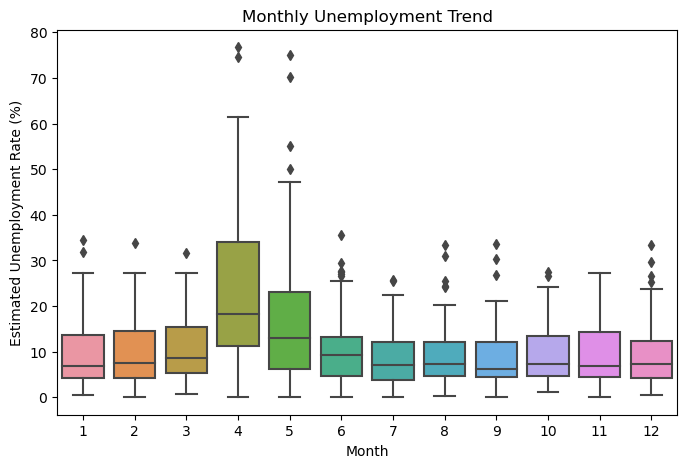

In [8]:
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(8,5))
sns.boxplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title('Monthly Unemployment Trend')
plt.show()

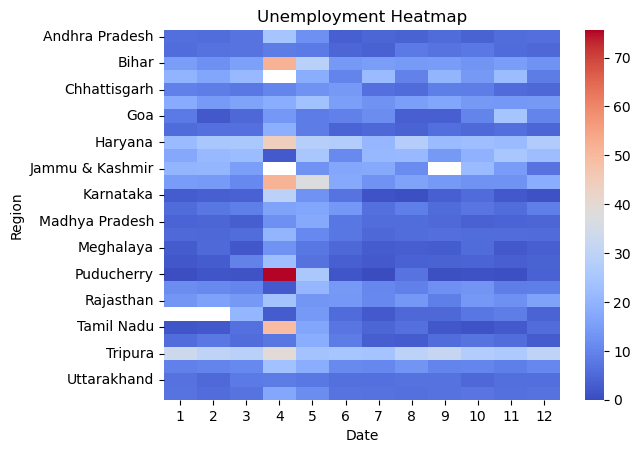

In [9]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns=df['Date'].dt.month
)

sns.heatmap(pivot, cmap='coolwarm')
plt.title('Unemployment Heatmap')
plt.show()